# Scoping Review Analysis

Figures for the scoping review of spatio-temporal models of infectious disease. Styled after *The Economist*'s illustration conventions:

- Red flag tag + figure label at top-left
- Bold black title, grey deck (subtitle)
- Horizontal gridlines only, no box
- Curated 6-colour palette
- Source line along the bottom

All figures are written to **`exported_figures/`** as 300-dpi PNGs.

In [113]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

from review_plot_helpers import (
    FIG_DIR,
    ECON,
    TIME_RESOLUTION_ORDER,
    HORIZON_BAND_ORDER,
    METHOD_FAMILY_ORDER,
    code_bucket,
    configure_matplotlib,
    econ_axes,
    economist_frame,
    extract_countries,
    normalize_disease,
    prepare_time_features,
)

configure_matplotlib()


## Load the workbook

In [114]:
EXCEL_PATH = Path("Scoping_review_notes_on_papers.xlsx")
assert EXCEL_PATH.exists(), EXCEL_PATH

df_main     = pd.read_excel(EXCEL_PATH, sheet_name="Sheet1")
df_arch     = pd.read_excel(EXCEL_PATH, sheet_name="Model Architecture")
df_cov      = pd.read_excel(EXCEL_PATH, sheet_name="Covariates")
df_eval     = pd.read_excel(EXCEL_PATH, sheet_name="Evaluation & Performance")
df_interp   = pd.read_excel(EXCEL_PATH, sheet_name="Interpretation")
df_temporal = pd.read_excel(EXCEL_PATH, sheet_name="Temporal evolution methods")

# keep only included papers
def included(df, col_candidates=("Included", "Included?")):
    for c in col_candidates:
        if c in df.columns:
            return df[df[c].astype(str).str.strip().str.lower().isin(["yes", "y"])].copy()
    return df.copy()

df_main   = included(df_main)
df_arch   = included(df_arch)
df_cov    = included(df_cov)
df_eval   = included(df_eval)
df_interp = included(df_interp)
df_temporal = df_temporal.dropna(subset=["Year", "Method", "Category"]).copy()
df_temporal["Year"] = df_temporal["Year"].astype(int)

print(f"Included papers: {len(df_main)}")
print(f"Architecture  : {len(df_arch)}")
print(f"Covariates    : {len(df_cov)}")
print(f"Evaluation    : {len(df_eval)}")
print(f"Interpretation: {len(df_interp)}")
print(f"Temporal rows : {len(df_temporal)}")


Included papers: 93
Architecture  : 93
Covariates    : 93
Evaluation    : 93
Interpretation: 93
Temporal rows : 93


## Publication volume over time
A simple column chart of papers per year with the COVID-19 inflection annotated.

saved → /Users/zl17868/Documents/Review analysis/exported_figures/fig1_publications_by_year.png


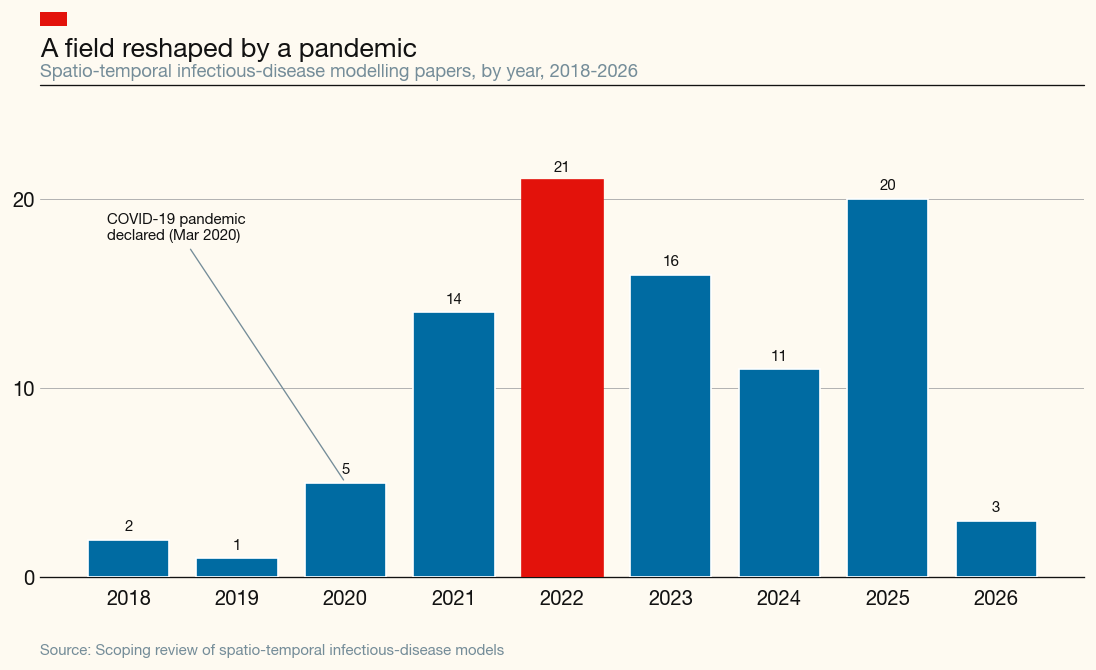

In [115]:
yr = (df_main["year"].dropna().astype(int).value_counts().sort_index())
yr = yr.reindex(range(int(yr.index.min()), int(yr.index.max()) + 1), fill_value=0)

fig = plt.figure(figsize=(10, 5.6))
ax = fig.add_axes([0.08, 0.14, 0.87, 0.68])
bars = ax.bar(yr.index.astype(str), yr.values, color=ECON["navy"], width=0.75, zorder=3)

# highlight the peak year in red
peak = int(yr.idxmax())
for bar, year in zip(bars, yr.index):
    if year == peak:
        bar.set_color(ECON["red"])

# value labels on top
for bar in bars:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, h + max(yr.values) * 0.015,
                f"{int(h)}", ha="center", va="bottom", fontsize=9,
                color=ECON["ink"])

# COVID-19 annotation
if 2020 in yr.index:
    x20 = list(yr.index).index(2020)
    ax.annotate("COVID-19 pandemic\ndeclared (Mar 2020)",
                xy=(x20, yr.loc[2020]),
                xytext=(x20 - 2.2, max(yr.values) * 0.85),
                fontsize=9, color=ECON["ink"],
                arrowprops=dict(arrowstyle="-", color=ECON["grey"], lw=0.8))

ax.set_ylabel("")
ax.set_xlabel("")
ax.set_ylim(0, max(yr.values) * 1.15)
ax.set_yticks(np.arange(0, max(yr.values) * 1.15, 10))
econ_axes(ax)

economist_frame(fig,
    title="A field reshaped by a pandemic",
    subtitle=f"Spatio-temporal infectious-disease modelling papers, by year, {int(yr.index.min())}-{int(yr.index.max())}")
_out = FIG_DIR / "fig1_publications_by_year.png"
fig.savefig(_out)
print(f"saved → {_out.resolve()}")
plt.show()


## Which diseases are studied
Horizontal bar chart ordered by frequency, Economist-style value labels at end of bars.

saved → /Users/zl17868/Documents/Review analysis/exported_figures/fig2_disease_breakdown.png


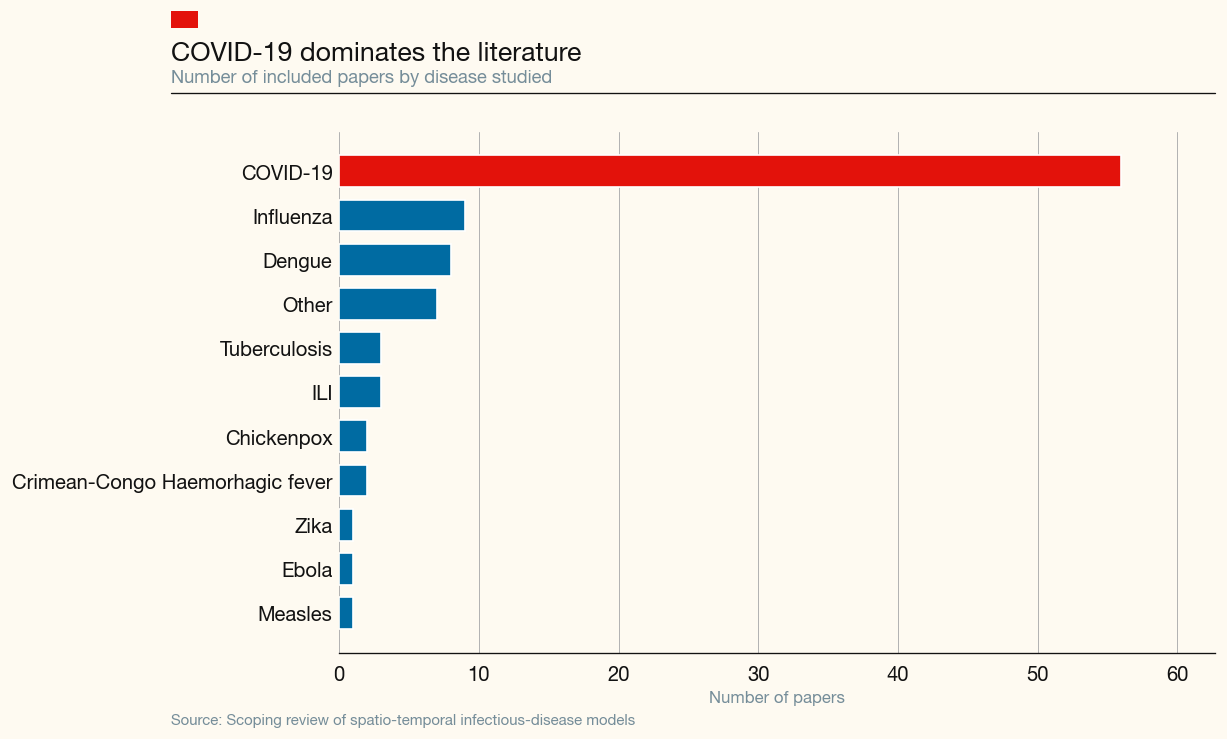

In [ ]:
dis = df_main["Disease"].fillna("Unspecified").astype(str).str.strip()
# Normalise common variants
dis = dis.str.replace(r"(?i)covid[-\s]?19", "COVID-19", regex=True)
dis = dis.str.replace(r"(?i)^influenza.*", "Influenza", regex=True)
dis_counts = dis.value_counts()

# collapse long tail
top = dis_counts.head(10)
if len(dis_counts) > 10:
    top["Other"] = dis_counts.iloc[10:].sum()
top = top.sort_values()

fig = plt.figure(figsize=(10, 6.2))
ax = fig.add_axes([0.22, 0.12, 0.73, 0.70])
colors = [ECON["red"] if d == top.idxmax() else ECON["navy"] for d in top.index]
ax.barh(top.index, top.values, color=colors, zorder=3, height=0.72)

for i, (d, v) in enumerate(top.items()):
    ax.text(v + max(top.values) * 0.01, i, f"{int(v)}",
            va="center", ha="left", fontsize=10, color=ECON["ink"])

ax.set_xlim(0, max(top.values) * 1.12)
ax.set_xlabel("Number of papers", fontsize=10, color=ECON["grey"])
econ_axes(ax, grid_axis="x")
ax.tick_params(axis="y", pad=4)

economist_frame(fig,
    title="COVID-19 dominates the literature",
    subtitle="Number of included papers by disease studied")
_out = FIG_DIR / "fig2_disease_breakdown.png"
fig.savefig(_out)
print(f"saved → {_out.resolve()}")
plt.show()


## Study location — country / region

Horizontal bar chart of the countries covered by the included studies. Many papers cover more than one country, so we count each country mentioned in the `Region` field.


saved → /Users/zl17868/Documents/Review analysis/exported_figures/fig_countries.png


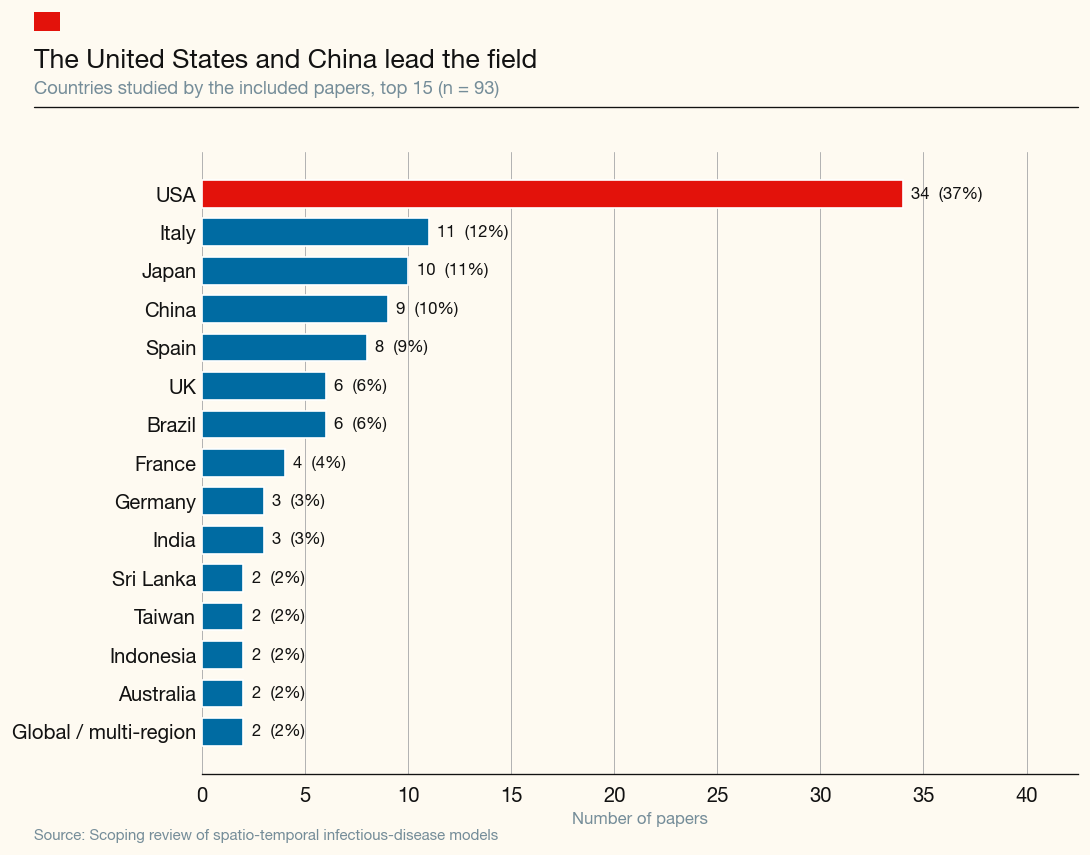

In [117]:
country_series = df_main["Region"].apply(extract_countries)
country_counts = pd.Series([c for sub in country_series for c in sub]).value_counts()

top = country_counts.head(15).sort_values()
n_papers = len(df_main)

fig = plt.figure(figsize=(10, 7.2))
ax = fig.add_axes([0.22, 0.10, 0.73, 0.72])
colors = [ECON["red"] if v == top.max() else ECON["navy"] for v in top.values]
ax.barh(top.index, top.values, color=colors, height=0.72, zorder=3)
for i, (k, v) in enumerate(top.items()):
    pct = v / n_papers * 100
    ax.text(v + max(top.values) * 0.012, i,
            f"{int(v)}  ({pct:.0f}%)", va="center", ha="left",
            fontsize=10, color=ECON["ink"])

ax.set_xlim(0, max(top.values) * 1.25)
ax.set_xlabel("Number of papers", fontsize=10, color=ECON["grey"])
econ_axes(ax, grid_axis="x")

economist_frame(fig,
    title="The United States and China lead the field",
    subtitle=f"Countries studied by the included papers, top 15 (n = {n_papers})")
_out = FIG_DIR / "fig_countries.png"
fig.savefig(_out)
print(f"saved → {_out.resolve()}")
plt.show()


## Temporal and forecast characteristics

The workbook does not contain latitude/longitude, so geographic coverage is shown with the existing country bar chart above. The cells below add four new views: temporal resolution, forecast horizon bands, method family versus explainability, and forecast horizon by method family.


In [118]:
df_time = prepare_time_features(df_main)


## Temporal resolution distribution

Bar chart of the reporting cadence used in the included studies.


saved -> /Users/zl17868/Documents/Review analysis/exported_figures/fig_temporal_resolution_distribution.png


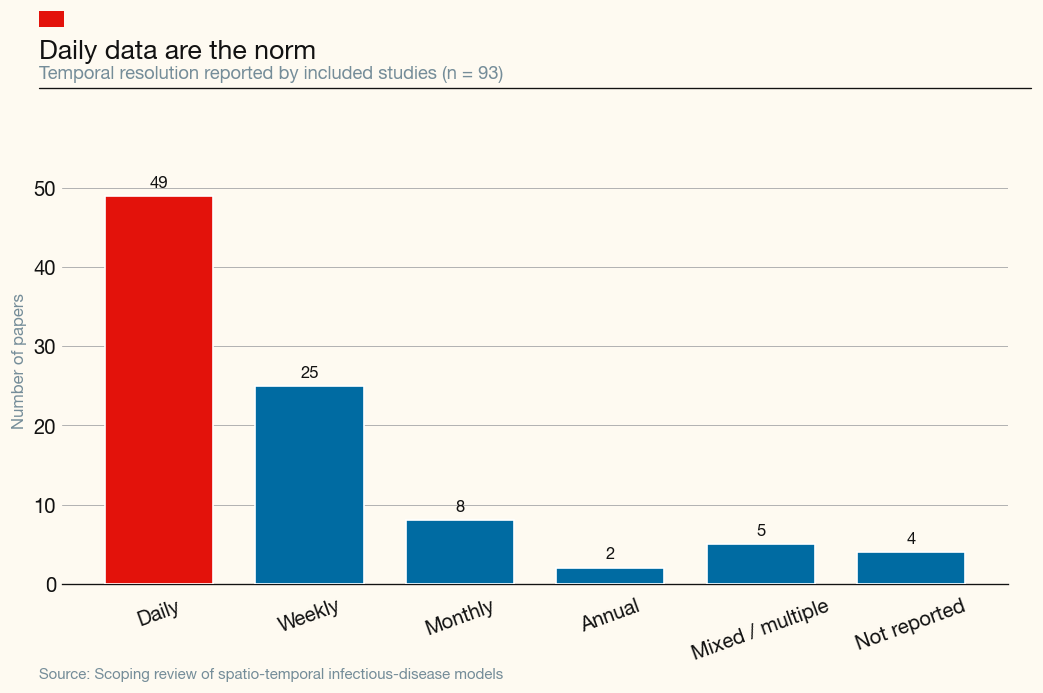

In [119]:
resolution_counts = (df_time["temporal_resolution_group"]
                     .value_counts()
                     .reindex(TIME_RESOLUTION_ORDER, fill_value=0))
resolution_counts = resolution_counts[resolution_counts > 0]

fig = plt.figure(figsize=(9.5, 5.8))
ax = fig.add_axes([0.10, 0.16, 0.83, 0.64])
colors = [ECON["red"] if v == resolution_counts.max() else ECON["navy"] for v in resolution_counts.values]
bars = ax.bar(resolution_counts.index, resolution_counts.values, color=colors, width=0.72, zorder=3)

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + max(resolution_counts.values) * 0.015,
            f"{int(h)}", ha="center", va="bottom", fontsize=10, color=ECON["ink"])

ax.set_ylim(0, max(resolution_counts.values) * 1.15)
ax.set_xlabel("")
ax.set_ylabel("Number of papers", fontsize=10, color=ECON["grey"])
ax.tick_params(axis="x", rotation=20)
econ_axes(ax, grid_axis="y")

economist_frame(fig,
    title="Daily data are the norm",
    subtitle=f"Temporal resolution reported by included studies (n = {len(df_time)})")
_out = FIG_DIR / "fig_temporal_resolution_distribution.png"
fig.savefig(_out)
print(f"saved -> {_out.resolve()}")
plt.show()


## Temporal resolution by disease

Stacked horizontal bars showing which reporting cadence is used for each major disease group.


saved -> /Users/zl17868/Documents/Review analysis/exported_figures/fig_disease_temporal_resolution.png


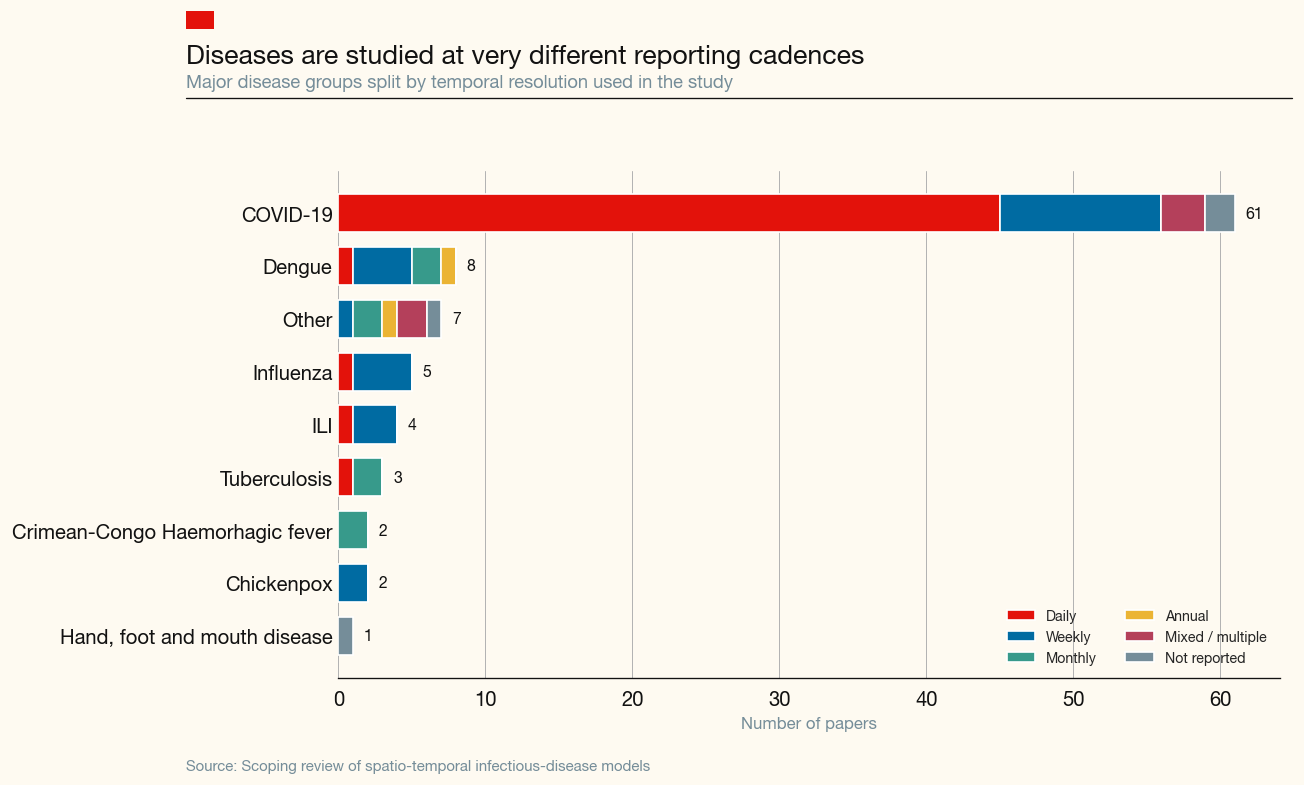

In [120]:
disease_time = df_time.copy()
disease_time["disease_group"] = disease_time["Disease"].apply(normalize_disease)
disease_counts = disease_time["disease_group"].value_counts()
top_diseases = disease_counts.head(8).index.tolist()
disease_time["disease_plot"] = disease_time["disease_group"].where(
    disease_time["disease_group"].isin(top_diseases), "Other"
)

resolution_cols = ["Daily", "Weekly", "Biweekly", "Monthly", "Annual", "Mixed / multiple", "Other", "Not reported"]
disease_resolution = (
    disease_time.groupby(["disease_plot", "temporal_resolution_group"]).size()
    .unstack(fill_value=0)
)
for col in resolution_cols:
    if col not in disease_resolution.columns:
        disease_resolution[col] = 0
disease_resolution = disease_resolution[resolution_cols]
row_order = disease_time["disease_plot"].value_counts().index.tolist()
disease_resolution = disease_resolution.reindex(row_order, fill_value=0)

fig = plt.figure(figsize=(10.6, 6.6))
ax = fig.add_axes([0.20, 0.14, 0.74, 0.64])
resolution_colors = {
    "Daily": ECON["red"],
    "Weekly": ECON["navy"],
    "Biweekly": ECON["cyan"],
    "Monthly": ECON["teal"],
    "Annual": ECON["gold"],
    "Mixed / multiple": ECON["plum"],
    "Other": "#9AA7AD",
    "Not reported": ECON["grey"],
}

left = np.zeros(len(disease_resolution))
for col in resolution_cols:
    vals = disease_resolution[col].values
    if vals.sum() == 0:
        continue
    ax.barh(disease_resolution.index, vals, left=left, height=0.72,
            color=resolution_colors[col], label=col, zorder=3)
    left += vals

for i, total in enumerate(disease_resolution.sum(axis=1).values):
    ax.text(total + max(disease_resolution.sum(axis=1).values) * 0.012, i, f"{int(total)}",
            va="center", ha="left", fontsize=9.5, color=ECON["ink"])

ax.set_xlabel("Number of papers", fontsize=10, color=ECON["grey"])
ax.set_ylabel("")
econ_axes(ax, grid_axis="x")
ax.legend(loc="lower right", fontsize=8.5, ncol=2)

# put the most common disease at the top
ax.invert_yaxis()

economist_frame(fig,
    title="Diseases are studied at very different reporting cadences",
    subtitle="Major disease groups split by temporal resolution used in the study")
_out = FIG_DIR / "fig_disease_temporal_resolution.png"
fig.savefig(_out)
print(f"saved -> {_out.resolve()}")
plt.show()


## Forecast horizon bands

Bar chart grouping each study by its longest forecast horizon: short (up to 2 weeks), medium (2-4 weeks), or longer-term (>4 weeks).


saved -> /Users/zl17868/Documents/Review analysis/exported_figures/fig_forecast_horizon_bands.png


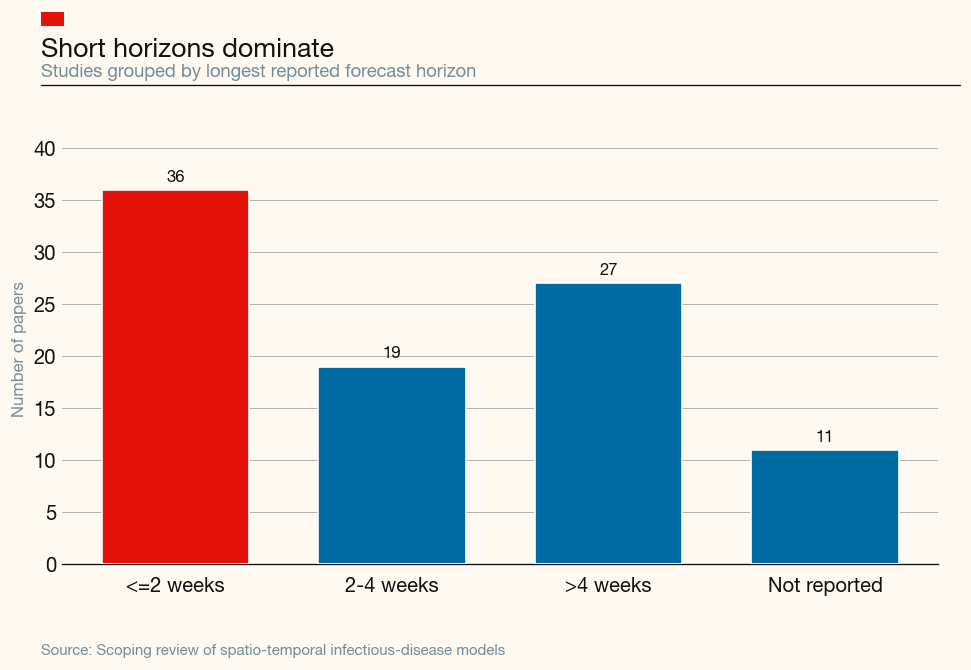

In [121]:
horizon_band_counts = (df_time["forecast_horizon_band"]
                       .value_counts()
                       .reindex(HORIZON_BAND_ORDER, fill_value=0))

fig = plt.figure(figsize=(8.8, 5.6))
ax = fig.add_axes([0.10, 0.16, 0.83, 0.64])
colors = [ECON["red"] if k == "<=2 weeks" else ECON["navy"] for k in horizon_band_counts.index]
bars = ax.bar(horizon_band_counts.index, horizon_band_counts.values, color=colors, width=0.68, zorder=3)

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + max(horizon_band_counts.values) * 0.015,
            f"{int(h)}", ha="center", va="bottom", fontsize=10, color=ECON["ink"])

ax.set_ylim(0, max(horizon_band_counts.values) * 1.15)
ax.set_xlabel("")
ax.set_ylabel("Number of papers", fontsize=10, color=ECON["grey"])
econ_axes(ax, grid_axis="y")

economist_frame(fig,
    title="Short horizons dominate",
    subtitle="Studies grouped by longest reported forecast horizon")
_out = FIG_DIR / "fig_forecast_horizon_bands.png"
fig.savefig(_out)
print(f"saved -> {_out.resolve()}")
plt.show()


## Method family versus explainability

Stacked bars comparing broad method families and whether the paper claims explainability.


saved -> /Users/zl17868/Documents/Review analysis/exported_figures/fig_method_explainability_stacked.png


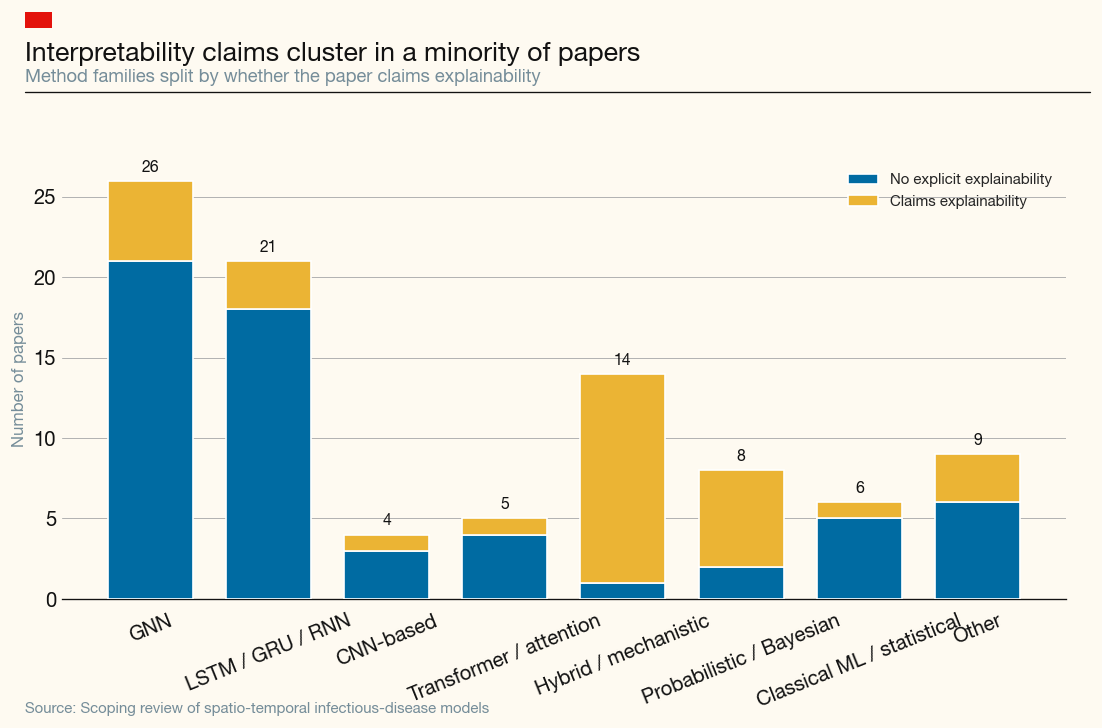

In [122]:
explain_counts = (df_time.groupby(["method_family", "explainability_group"]).size()
                  .unstack(fill_value=0)
                  .reindex(METHOD_FAMILY_ORDER, fill_value=0))
explain_counts = explain_counts.loc[explain_counts.sum(axis=1) > 0]
explain_cols = ["No explicit explainability", "Claims explainability"]
for col in explain_cols:
    if col not in explain_counts.columns:
        explain_counts[col] = 0
explain_counts = explain_counts[explain_cols]

fig = plt.figure(figsize=(10.2, 6.1))
ax = fig.add_axes([0.11, 0.18, 0.82, 0.60])

bottom = np.zeros(len(explain_counts))
colors = {
    "No explicit explainability": ECON["navy"],
    "Claims explainability": ECON["gold"],
}
for col in explain_cols:
    vals = explain_counts[col].values
    ax.bar(explain_counts.index, vals, bottom=bottom, color=colors[col], width=0.72, label=col, zorder=3)
    bottom += vals

for x, total in enumerate(explain_counts.sum(axis=1).values):
    ax.text(x, total + max(explain_counts.sum(axis=1).values) * 0.015, f"{int(total)}",
            ha="center", va="bottom", fontsize=9.5, color=ECON["ink"])

ax.set_xlabel("")
ax.set_ylabel("Number of papers", fontsize=10, color=ECON["grey"])
ax.tick_params(axis="x", rotation=22)
econ_axes(ax, grid_axis="y")
ax.legend(loc="upper right", fontsize=9)

economist_frame(fig,
    title="Interpretability claims cluster in a minority of papers",
    subtitle="Method families split by whether the paper claims explainability")
_out = FIG_DIR / "fig_method_explainability_stacked.png"
fig.savefig(_out)
print(f"saved -> {_out.resolve()}")
plt.show()


## Forecast horizon by method family

Stacked bars comparing broad method families across forecast-horizon bands: up to 2 weeks, 2-4 weeks, and more than 4 weeks.


saved -> /Users/zl17868/Documents/Review analysis/exported_figures/fig_forecast_horizon_by_method.png


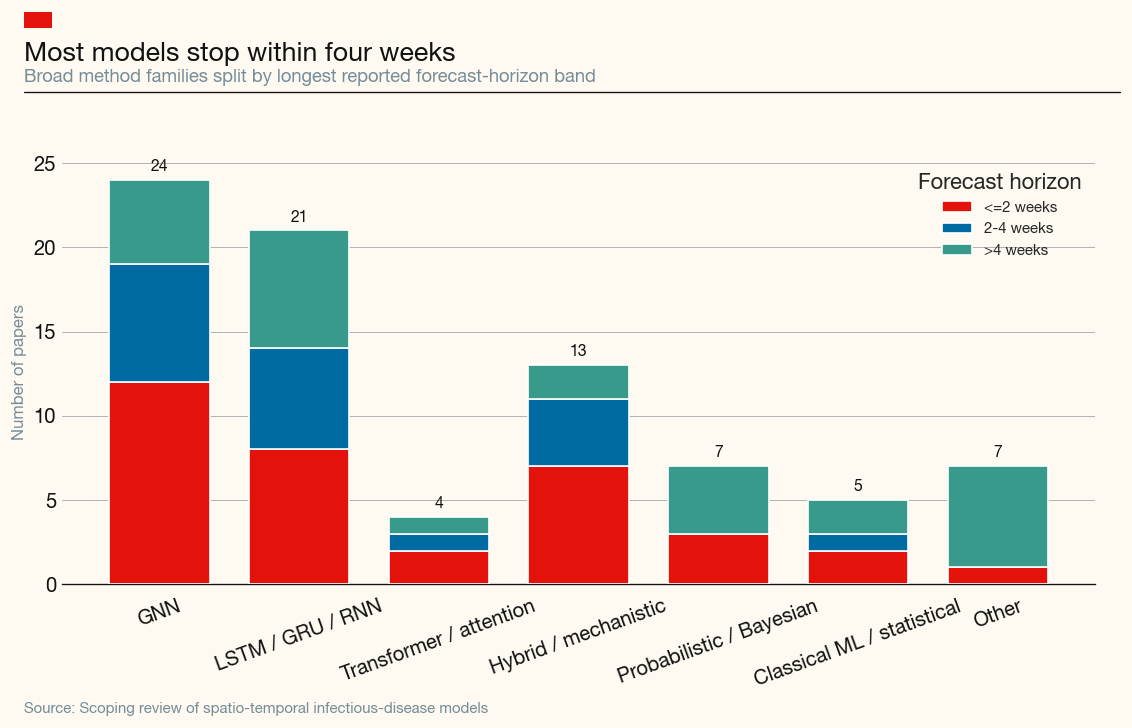

In [123]:
method_horizon = df_time[df_time["forecast_horizon_band"] != "Not reported"].copy()
method_rank = method_horizon["method_family"].value_counts()
selected_methods = [m for m in METHOD_FAMILY_ORDER if method_rank.get(m, 0) >= 4]
method_horizon = method_horizon[method_horizon["method_family"].isin(selected_methods)].copy()

method_horizon_counts = (
    method_horizon.groupby(["method_family", "forecast_horizon_band"]).size()
    .unstack(fill_value=0)
    .reindex(selected_methods, fill_value=0)
)
plot_bands = ["<=2 weeks", "2-4 weeks", ">4 weeks"]
for band in plot_bands:
    if band not in method_horizon_counts.columns:
        method_horizon_counts[band] = 0
method_horizon_counts = method_horizon_counts[plot_bands]

fig = plt.figure(figsize=(10.5, 6.1))
ax = fig.add_axes([0.11, 0.20, 0.82, 0.58])

band_colors = {
    "<=2 weeks": ECON["red"],
    "2-4 weeks": ECON["navy"],
    ">4 weeks": ECON["teal"],
}

bottom = np.zeros(len(method_horizon_counts))
for band in plot_bands:
    vals = method_horizon_counts[band].values
    ax.bar(method_horizon_counts.index, vals, bottom=bottom, width=0.72,
           color=band_colors[band], label=band, zorder=3)
    bottom += vals

for x, total in enumerate(method_horizon_counts.sum(axis=1).values):
    ax.text(x, total + max(method_horizon_counts.sum(axis=1).values) * 0.015, f"{int(total)}",
            ha="center", va="bottom", fontsize=9.5, color=ECON["ink"])

ax.set_ylabel("Number of papers", fontsize=10, color=ECON["grey"])
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=20)
econ_axes(ax, grid_axis="y")
ax.legend(loc="upper right", fontsize=9, title="Forecast horizon")

economist_frame(fig,
    title="Most models stop within four weeks",
    subtitle="Broad method families split by longest reported forecast-horizon band")
_out = FIG_DIR / "fig_forecast_horizon_by_method.png"
fig.savefig(_out)
print(f"saved -> {_out.resolve()}")
plt.show()


## Method category over time
Stacked-area chart of method families by publication year.

saved → /Users/zl17868/Documents/Review analysis/exported_figures/fig3_method_category_over_time.png


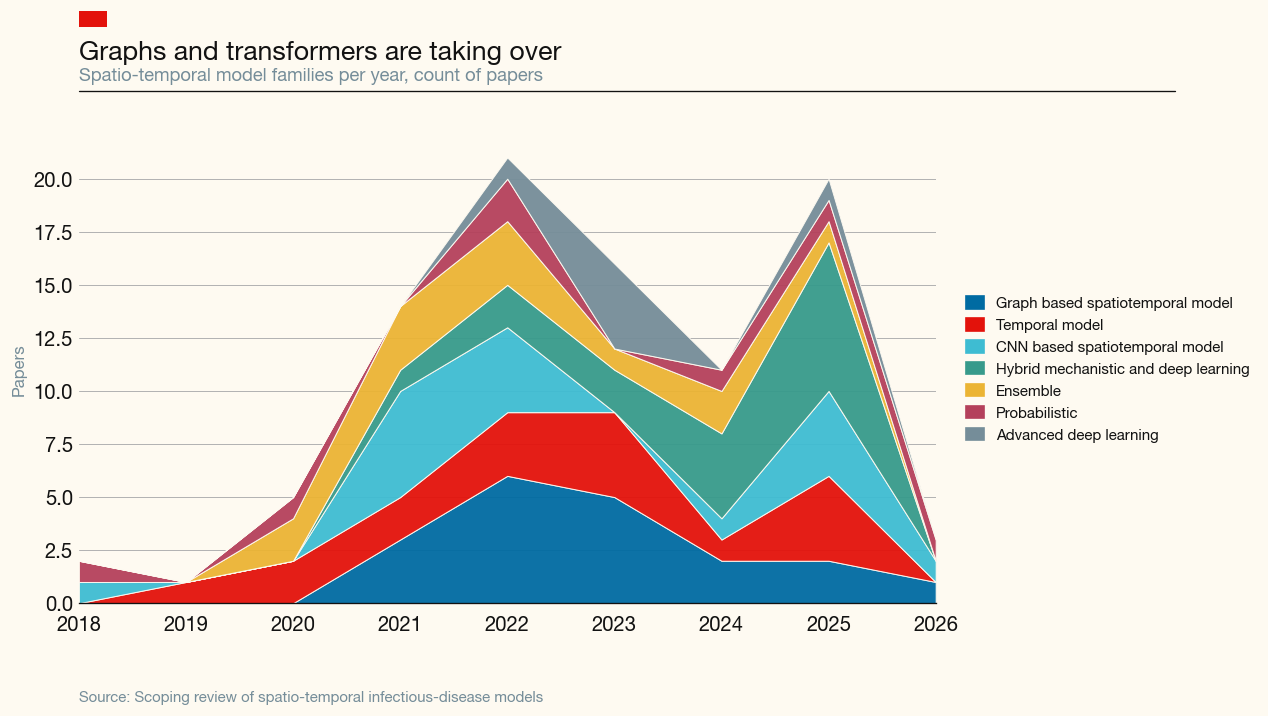

In [124]:
tev = df_temporal.copy()
tev["Category"] = tev["Category"].astype(str).str.strip()

# Pivot: rows = year, cols = category, values = count
pivot = (tev.groupby(["Year", "Category"]).size()
             .unstack(fill_value=0)
             .sort_index())
# ensure continuous years
pivot = pivot.reindex(range(pivot.index.min(), pivot.index.max() + 1), fill_value=0)
# rank by total size so bigger categories sit at the bottom
order = pivot.sum().sort_values(ascending=False).index.tolist()
pivot = pivot[order]

cat_colors = [ECON[c] for c in ["navy", "red", "cyan", "teal", "gold", "plum", "grey"]]
cat_colors = (cat_colors * ((len(order) // len(cat_colors)) + 1))[:len(order)]

fig = plt.figure(figsize=(10.5, 6))
ax = fig.add_axes([0.08, 0.16, 0.68, 0.65])
ax.stackplot(pivot.index, pivot.T.values, labels=pivot.columns,
             colors=cat_colors, edgecolor=ECON["paper"], linewidth=0.6, alpha=0.95)

ax.set_xlim(pivot.index.min(), pivot.index.max())
ax.set_xticks(pivot.index)
ax.tick_params(axis="x", rotation=0)
ax.set_ylabel("Papers", fontsize=10, color=ECON["grey"])
econ_axes(ax, grid_axis="y")

# legend outside right
handles = [Rectangle((0, 0), 1, 1, color=c) for c in cat_colors]
ax.legend(handles, pivot.columns, loc="center left", bbox_to_anchor=(1.02, 0.5),
          fontsize=9, handlelength=1.2, handleheight=0.9, labelcolor=ECON["ink"])

economist_frame(fig,
    title="Graphs and transformers are taking over",
    subtitle="Spatio-temporal model families per year, count of papers")
_out = FIG_DIR / "fig3_method_category_over_time.png"
fig.savefig(_out)
print(f"saved → {_out.resolve()}")
plt.show()


## Core model architectures
Lollipop chart of deep-learning backbones.

saved → /Users/zl17868/Documents/Review analysis/exported_figures/fig4_core_architectures.png


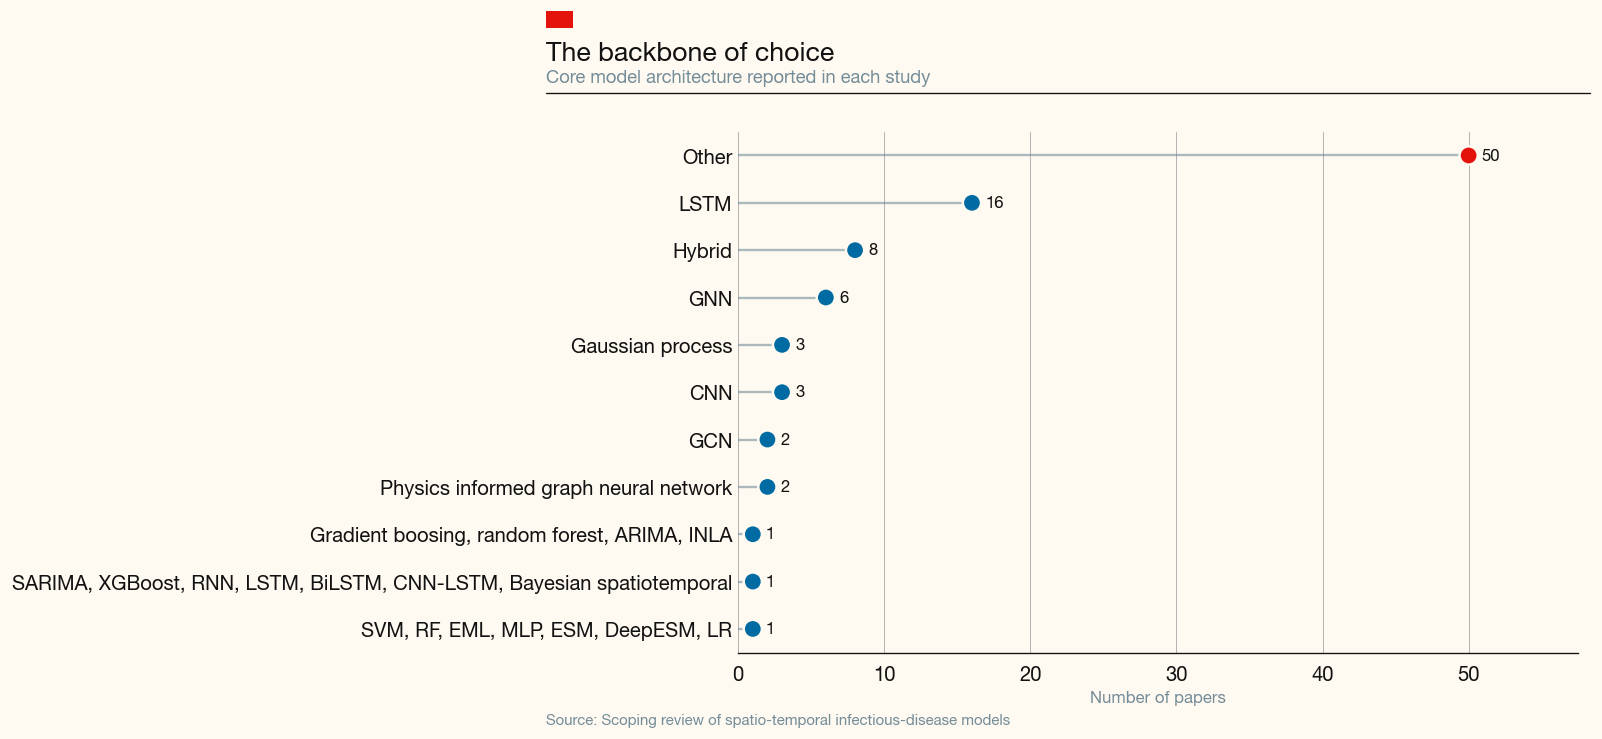

In [125]:
arch_col = "Core model (LSTM / GNN / Transformer / Hybrid)"
core = (df_arch[arch_col].dropna().astype(str).str.strip()
        .str.replace(r"\s+", " ", regex=True))
# Normalise casing
core = core.str.replace(r"(?i)^gnn.*", "GNN", regex=True)
core = core.str.replace(r"(?i)^lstm.*", "LSTM", regex=True)
core = core.str.replace(r"(?i)^transformer.*", "Transformer", regex=True)
core = core.str.replace(r"(?i)^hybrid.*", "Hybrid", regex=True)
core = core.str.replace(r"(?i)^cnn.*", "CNN", regex=True)

core_counts = core.value_counts()
top = core_counts.head(10)
if len(core_counts) > 10:
    top["Other"] = core_counts.iloc[10:].sum()
top = top.sort_values()

fig = plt.figure(figsize=(10, 6.2))
ax = fig.add_axes([0.24, 0.12, 0.70, 0.70])

ys = np.arange(len(top))
ax.hlines(ys, 0, top.values, color=ECON["grey"], linewidth=1.4, alpha=0.6, zorder=2)
colors = [ECON["red"] if v == top.max() else ECON["navy"] for v in top.values]
ax.scatter(top.values, ys, s=120, color=colors, zorder=3, edgecolor=ECON["paper"], linewidth=1.5)
for y, v in zip(ys, top.values):
    ax.text(v + max(top.values) * 0.018, y, str(int(v)),
            va="center", ha="left", fontsize=10, color=ECON["ink"])

ax.set_yticks(ys)
ax.set_yticklabels(top.index)
ax.set_xlim(0, max(top.values) * 1.15)
ax.set_xlabel("Number of papers", fontsize=10, color=ECON["grey"])
econ_axes(ax, grid_axis="x")

economist_frame(fig,
    title="The backbone of choice",
    subtitle="Core model architecture reported in each study")
_out = FIG_DIR / "fig4_core_architectures.png"
fig.savefig(_out)
print(f"saved → {_out.resolve()}")
plt.show()


## Covariates used
Horizontal bar chart of how often each covariate family is used.

saved → /Users/zl17868/Documents/Review analysis/exported_figures/fig5_covariates.png


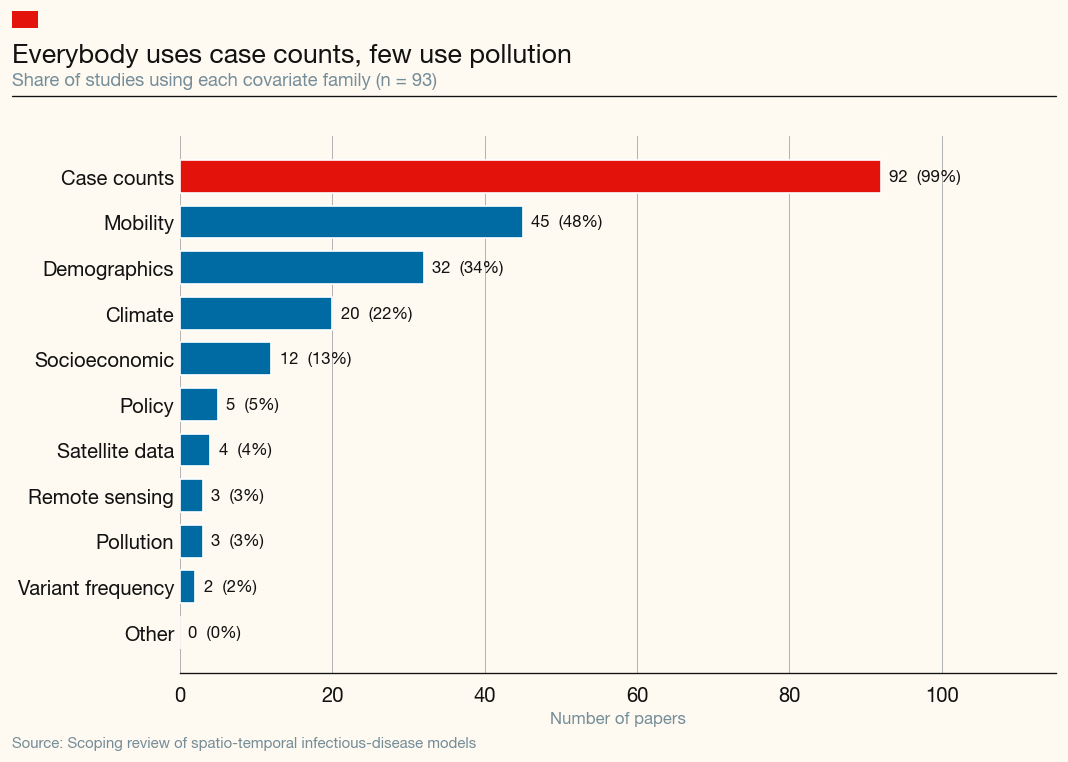

In [126]:
cov_cols = ["Case counts", "Mobility", "Climate", "Pollution",
            "Socioeconomic", "Policy", "Variant frequency",
            "Satellite data", "Remote sensing", "Demographics", "Other"]
cov_present = [c for c in cov_cols if c in df_cov.columns]
cov_counts = (df_cov[cov_present].apply(pd.to_numeric, errors="coerce")
                                  .fillna(0).astype(int)
                                  .sum().sort_values())
n_papers = len(df_cov)

fig = plt.figure(figsize=(10, 6.4))
ax = fig.add_axes([0.22, 0.12, 0.73, 0.70])
colors = [ECON["red"] if v == cov_counts.max() else ECON["navy"] for v in cov_counts.values]
ax.barh(cov_counts.index, cov_counts.values, color=colors, height=0.72, zorder=3)
for i, (k, v) in enumerate(cov_counts.items()):
    pct = v / n_papers * 100
    ax.text(v + max(cov_counts.values) * 0.012, i,
            f"{int(v)}  ({pct:.0f}%)", va="center", ha="left",
            fontsize=10, color=ECON["ink"])

ax.set_xlim(0, max(cov_counts.values) * 1.25)
ax.set_xlabel("Number of papers", fontsize=10, color=ECON["grey"])
econ_axes(ax, grid_axis="x")

economist_frame(fig,
    title="Everybody uses case counts, few use pollution",
    subtitle=f"Share of studies using each covariate family (n = {n_papers})")
_out = FIG_DIR / "fig5_covariates.png"
fig.savefig(_out)
print(f"saved → {_out.resolve()}")
plt.show()


## Evaluation metrics reported

saved → /Users/zl17868/Documents/Review analysis/exported_figures/fig6_evaluation_metrics.png


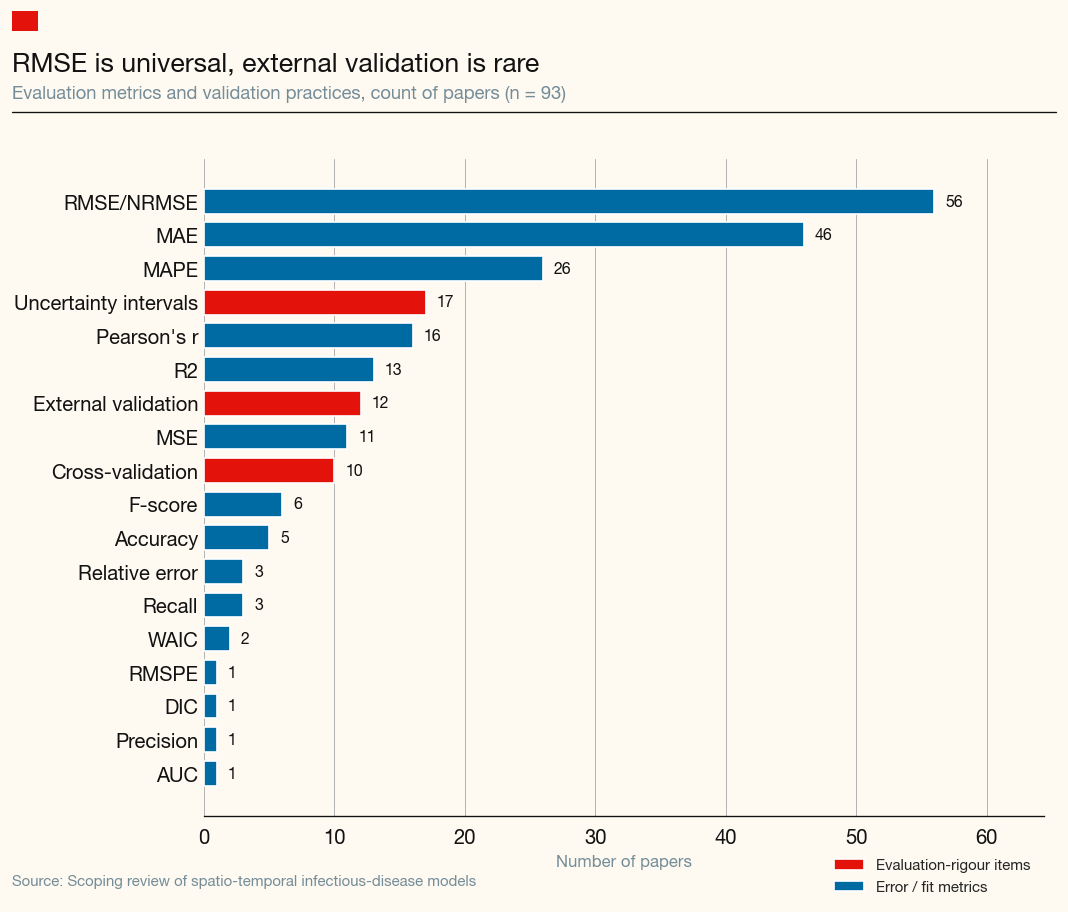

In [127]:
metric_cols = ["RMSE/NRMSE", "MAE", "MAPE", "AUC", "Cross-validation?",
               "External validation?", "Uncertainty interval reported?",
               "R2", "F-score", "RMSPE", "Pearsons",
               "Watanabe Akaike information criterion",
               "Deviance information criterion",
               "Precision", "Recall", "Accuracy", "Relative error", "MSE"]
pretty_rename = {
    "Cross-validation?": "Cross-validation",
    "External validation?": "External validation",
    "Uncertainty interval reported?": "Uncertainty intervals",
    "Watanabe Akaike information criterion": "WAIC",
    "Deviance information criterion": "DIC",
    "Pearsons": "Pearson's r",
}
metric_present = [c for c in metric_cols if c in df_eval.columns]
metric_counts = (df_eval[metric_present].apply(pd.to_numeric, errors="coerce")
                                         .fillna(0).astype(int).sum())
metric_counts.index = [pretty_rename.get(c, c) for c in metric_counts.index]
metric_counts = metric_counts.sort_values()
n_eval = len(df_eval)

fig = plt.figure(figsize=(10, 7.6))
ax = fig.add_axes([0.24, 0.10, 0.70, 0.72])

# highlight the three evaluation-rigour items
rigour = {"Cross-validation", "External validation", "Uncertainty intervals"}
colors = [ECON["red"] if k in rigour else ECON["navy"] for k in metric_counts.index]
ax.barh(metric_counts.index, metric_counts.values, color=colors, height=0.74, zorder=3)
for i, (k, v) in enumerate(metric_counts.items()):
    ax.text(v + max(metric_counts.values) * 0.015, i, f"{int(v)}",
            va="center", ha="left", fontsize=9.5, color=ECON["ink"])

ax.set_xlim(0, max(metric_counts.values) * 1.15)
ax.set_xlabel("Number of papers", fontsize=10, color=ECON["grey"])
econ_axes(ax, grid_axis="x")

# legend for the red highlight
from matplotlib.patches import Patch
legend_els = [Patch(facecolor=ECON["red"], label="Evaluation-rigour items"),
              Patch(facecolor=ECON["navy"], label="Error / fit metrics")]
ax.legend(handles=legend_els, loc="lower right", fontsize=9, bbox_to_anchor=(1.0, -0.14))

economist_frame(fig,
    title="RMSE is universal, external validation is rare",
    subtitle=f"Evaluation metrics and validation practices, count of papers (n = {n_eval})")
_out = FIG_DIR / "fig6_evaluation_metrics.png"
fig.savefig(_out)
print(f"saved → {_out.resolve()}")
plt.show()


## Interpretation and downstream use

saved → /Users/zl17868/Documents/Review analysis/exported_figures/fig7_interpretation.png


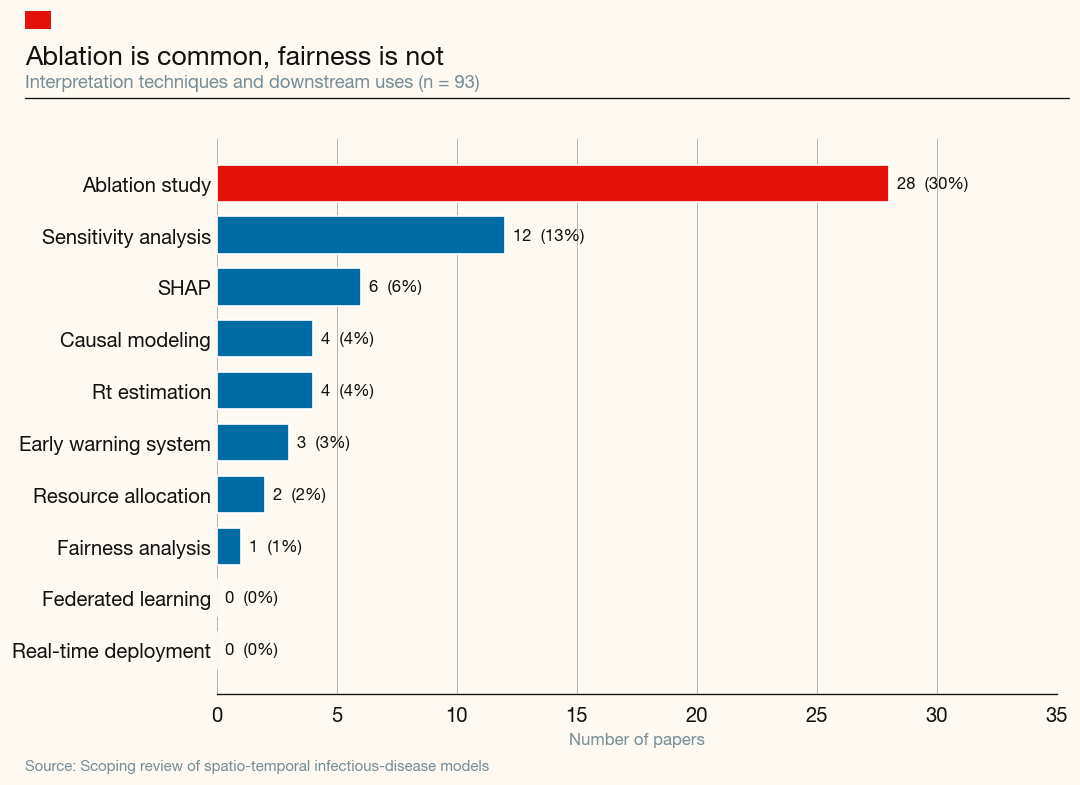

In [128]:
interp_cols = ["SHAP", "Sensitivity analysis", "Rt estimation", "Causal modeling",
                "Early warning system", "Resource allocation", "Real-time deployment",
                "Federated learning", "Fairness analysis", "Ablation study "]
present = [c for c in interp_cols if c in df_interp.columns]
counts = (df_interp[present].apply(pd.to_numeric, errors="coerce")
                             .fillna(0).astype(int).sum())
counts.index = [c.strip() for c in counts.index]
counts = counts.sort_values()
n = len(df_interp)

fig = plt.figure(figsize=(10, 6.6))
ax = fig.add_axes([0.24, 0.12, 0.70, 0.70])
colors = [ECON["red"] if v == counts.max() else ECON["navy"] for v in counts.values]
ax.barh(counts.index, counts.values, color=colors, height=0.72, zorder=3)
for i, (k, v) in enumerate(counts.items()):
    pct = v / n * 100
    ax.text(v + max(counts.values) * 0.012, i, f"{int(v)}  ({pct:.0f}%)",
            va="center", ha="left", fontsize=10, color=ECON["ink"])

ax.set_xlim(0, max(counts.values) * 1.25)
ax.set_xlabel("Number of papers", fontsize=10, color=ECON["grey"])
econ_axes(ax, grid_axis="x")

economist_frame(fig,
    title="Ablation is common, fairness is not",
    subtitle=f"Interpretation techniques and downstream uses (n = {n})")
_out = FIG_DIR / "fig7_interpretation.png"
fig.savefig(_out)
print(f"saved → {_out.resolve()}")
plt.show()


## Code availability
Donut chart for code availability (URL / repository link = available).

saved → /Users/zl17868/Documents/Review analysis/exported_figures/fig8_transparency.png


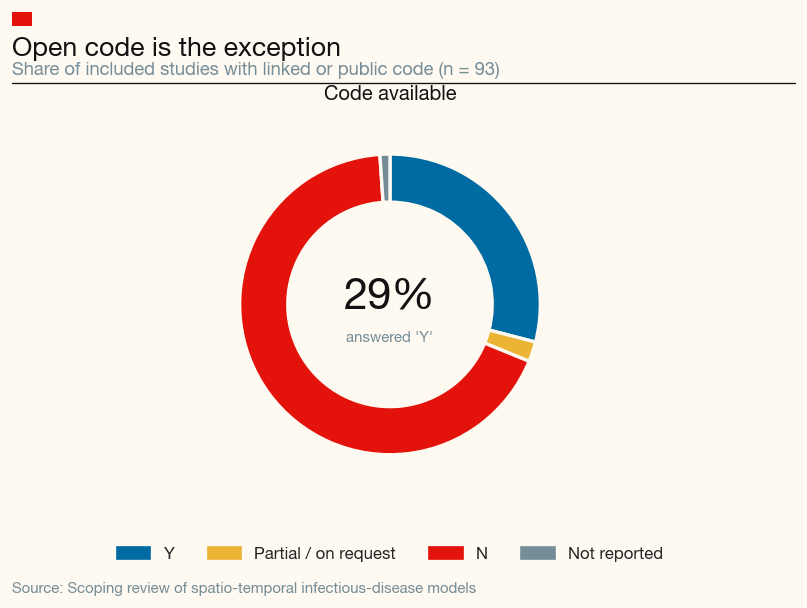

In [129]:
panels = {
    "Code available": code_bucket(df_main["Code available? (Y/N)"]),
}

level_order = ["Y", "Partial / on request", "N", "Not reported"]
level_colors = {
    "Y": ECON["navy"],
    "Partial / on request": ECON["gold"],
    "N": ECON["red"],
    "Not reported": ECON["grey"],
}

fig = plt.figure(figsize=(7.5, 5.4))
axes = [fig.add_axes([0.2, 0.18, 0.6, 0.58])]

for ax, (title, series) in zip(axes, panels.items()):
    counts = series.value_counts().reindex(level_order, fill_value=0)
    total = counts.sum()
    yes_pct = counts["Y"] / total * 100 if total else 0
    wedges, _ = ax.pie(
        counts.values,
        colors=[level_colors[l] for l in counts.index],
        startangle=90, counterclock=False,
        wedgeprops=dict(width=0.32, edgecolor=ECON["paper"], linewidth=2),
    )
    ax.text(0, 0.05, f"{yes_pct:.0f}%", ha="center", va="center",
            fontsize=26, fontweight="bold", color=ECON["ink"])
    ax.text(0, -0.22, "answered 'Y'", ha="center", va="center",
            fontsize=9, color=ECON["grey"])
    ax.set_title(title, fontsize=12, fontweight="bold", color=ECON["ink"], pad=10)

# shared legend
legend_patches = [Rectangle((0, 0), 1, 1, color=level_colors[l]) for l in level_order]
fig.legend(legend_patches, level_order, loc="lower center", ncol=4,
           bbox_to_anchor=(0.5, 0.05), frameon=False, fontsize=10)

economist_frame(fig,
    title="Open code is the exception",
    subtitle=f"Share of included studies with linked or public code (n = {len(df_main)})",
    top=0.82)
_out = FIG_DIR / "fig8_transparency.png"
fig.savefig(_out)
print(f"saved → {_out.resolve()}")
plt.show()


## Summary table
Quick numerical snapshot for the write-up.

In [130]:
summary = {
    "Included papers": len(df_main),
    "Year range":      f"{int(df_main['year'].min())}–{int(df_main['year'].max())}",
    "Peak year":        int(df_main['year'].value_counts().idxmax()),
    "Unique diseases":  df_main['Disease'].nunique(),
    "Code available (yes)":   int((code_bucket(df_main['Code available? (Y/N)']) == 'Y').sum()),
}
pd.Series(summary, name="value").to_frame()


,value
Included papers,93
Year range,2018–2026
Peak year,2022
Unique diseases,21
Code available (yes),27


## Exported figures

All charts are saved as PNGs in **`exported_figures/`** next to this notebook (300 dpi). Run the cell below to print the full path and file list.

In [131]:
out = sorted(FIG_DIR.glob("*.png"))
print(f"Export folder: {FIG_DIR.resolve()}\n")
for p in out:
    print(f"  {p.name}")
print(f"\nTotal: {len(out)} PNG file(s)")

Export folder: /Users/zl17868/Documents/Review analysis/exported_figures

  fig1_publications_by_year.png
  fig2_disease_breakdown.png
  fig3_method_category_over_time.png
  fig4_core_architectures.png
  fig5_covariates.png
  fig6_evaluation_metrics.png
  fig7_interpretation.png
  fig8_transparency.png
  fig_countries.png
  fig_disease_temporal_resolution.png
  fig_forecast_horizon_bands.png
  fig_forecast_horizon_by_method.png
  fig_method_explainability_stacked.png
  fig_temporal_resolution_distribution.png

Total: 14 PNG file(s)
